# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 7
- **Date:** 07.09.2026

---

In [18]:
# Student Identification

AUTHOR        = "Shrri Dharshan D R"
REGISTER_NO   = "23BPS1090"
COURSE        = "BCSE209P-Machine Learning Laboratory"
FACULTY       = "Dr. S. Shridevi"
INSTITUTION   = "SCOPE, VIT Chennai"
NOTEBOOK_ID   = "ML-LAB-07"

print("Notebook Loaded Successfully")

Notebook Loaded Successfully


In [19]:
# Notebook Fingerprint

import hashlib
import datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)

Notebook Fingerprint:
41f691b644cc84084a36a4822449a380f8203f28888c29fed98db7ea6abc0e14


# Experiment Details

## Objective

To implement a **Support Vector Machine (SVM) Classifier** using the
*Banknote Authentication Dataset* (UCI ML Repository, ID: 267),
in order to classify banknotes as **Genuine** or **Forged** based on 4 wavelet-transform
statistical features extracted from scanned images, and to evaluate the model using
standard classification metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC)
along with kernel comparison, C-parameter sensitivity study, 2D decision boundary
visualisation, and ROC curve analysis.

---

## Theory

A **Support Vector Machine (SVM)** is a supervised learning algorithm that finds the
optimal **hyperplane** separating two classes with the **maximum margin**. It is
particularly effective in high-dimensional spaces and remains robust even on compact
feature sets like the 4-feature Banknote dataset.

### Decision Hyperplane

For a binary classification problem with input $\mathbf{x} \in \mathbb{R}^d$,
the SVM decision boundary is a hyperplane defined by:

$$\mathbf{w}^\top \mathbf{x} + b = 0$$

where $\mathbf{w}$ is the weight vector (normal to the hyperplane) and $b$ is the bias.

The predicted class is:

$$\hat{y} = \text{sign}(\mathbf{w}^\top \mathbf{x} + b)$$

### Margin Maximisation (Hard-Margin SVM)

The **margin** is the perpendicular distance between the two parallel supporting hyperplanes
$\mathbf{w}^\top \mathbf{x} + b = \pm 1$:

$$\text{Margin} = \frac{2}{\|\mathbf{w}\|}$$

SVM maximises the margin by solving:

$$\min_{\mathbf{w},b}\ \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{subject to} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 \;\;\forall\, i$$

### Soft-Margin SVM (C-Parameter)

For non-linearly-separable data, slack variables $\xi_i \geq 0$ permit misclassifications:

$$\min_{\mathbf{w},b,\boldsymbol{\xi}}\ \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^{n}\xi_i$$

$$\text{subject to} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i,\quad \xi_i \geq 0$$

The **regularisation parameter $C$** controls the bias-variance trade-off:
- **Large $C$** → hard margin, low bias, high variance (penalises every misclassification heavily)
- **Small $C$** → soft margin, high bias, low variance (tolerates more violations for a wider margin)

### Kernel Trick

For non-linear boundaries, SVM maps data into a higher-dimensional feature space using a
kernel function $K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^\top \phi(\mathbf{x}_j)$:

$$f(\mathbf{x}) = \text{sign}\!\left(\sum_{i \in \text{SV}} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b\right)$$

**Common kernel functions:**

| Kernel | Formula |
|--------|---------|
| Linear | $K(\mathbf{x},\mathbf{z}) = \mathbf{x}^\top\mathbf{z}$ |
| Polynomial | $K(\mathbf{x},\mathbf{z}) = (\gamma\,\mathbf{x}^\top\mathbf{z} + r)^d$ |
| RBF (Gaussian) | $K(\mathbf{x},\mathbf{z}) = \exp\!\left(-\gamma\|\mathbf{x}-\mathbf{z}\|^2\right)$ |
| Sigmoid | $K(\mathbf{x},\mathbf{z}) = \tanh(\gamma\,\mathbf{x}^\top\mathbf{z} + r)$ |

### Support Vectors

**Support vectors** are the training points satisfying $\alpha_i > 0$ — those lying on
or within the margin boundaries. Only these points determine the position of the hyperplane.

### Feature Scaling

SVM margin and kernel distances depend on Euclidean norms.
**StandardScaler** standardises each feature to zero mean and unit variance:

$$x' = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

### Evaluation Metrics

| Metric | Formula |
|--------|---------|
| Accuracy | $\dfrac{TP + TN}{TP + TN + FP + FN}$ |
| Precision | $\dfrac{TP}{TP + FP}$ |
| Recall (Sensitivity) | $\dfrac{TP}{TP + FN}$ |
| F1-Score | $2 \cdot \dfrac{P \cdot R}{P + R}$ |
| ROC-AUC | Area under the Receiver Operating Characteristic curve |

---

## Dataset

- **Name:** Banknote Authentication Dataset
- **Source:** UCI Machine Learning Repository (ID: 267)  
  — https://archive.ics.uci.edu/dataset/267/banknote+authentication
- **Total Instances:** 1,372 banknote samples
- **Features (4):** Statistical measures from wavelet-transformed images —  
  variance, skewness, curtosis, entropy
- **Target:** `class` — 0 = Genuine, 1 = Forged
- **Class Distribution:** 762 Genuine (55.5%), 610 Forged (44.5%) — well balanced
- **Missing Values:** None
- **File Format:** CSV with no header (`.txt`)
- **Task Type:** Binary Classification
- **Licence:** CC BY 4.0


In [20]:
# Step 1 — Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os, zipfile, glob
import urllib.request

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")

All libraries imported successfully.


In [21]:
# Step 2 — Download and load the UCI Banknote Authentication dataset (ID: 267)

DATA_URL = "https://archive.ics.uci.edu/static/public/267/banknote+authentication.zip"
DATA_DIR = "banknote_data"
os.makedirs(DATA_DIR, exist_ok=True)

zip_path = os.path.join(DATA_DIR, "dataset.zip")
if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    print("Download complete.")
else:
    print("Dataset archive already present.")

with zipfile.ZipFile(zip_path) as zf:
    print("Zip contents:", zf.namelist())
    zf.extractall(DATA_DIR)

txt_files = glob.glob(os.path.join(DATA_DIR, "**", "*.txt"), recursive=True)
print("Text files found:", txt_files)

COLUMNS = ["variance", "skewness", "curtosis", "entropy", "class"]
df_raw = pd.read_csv(txt_files[0], header=None, names=COLUMNS)

print("\nDataset loaded successfully.")
print("Shape:", df_raw.shape)
print(df_raw.head())

Download complete.
Zip contents: ['data_banknote_authentication.txt']
Text files found: ['banknote_data\\data_banknote_authentication.txt']

Dataset loaded successfully.
Shape: (1372, 5)
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [22]:
# Step 3 — Dataset overview

print("Dataset  : Banknote Authentication")
print("Samples  :", df_raw.shape[0])
print("Columns  :", df_raw.shape[1])
print("Source   : UCI ML Repository (ID: 267)")
print("Target   : class (0 = Genuine, 1 = Forged)")

Dataset  : Banknote Authentication
Samples  : 1372
Columns  : 5
Source   : UCI ML Repository (ID: 267)
Target   : class (0 = Genuine, 1 = Forged)


In [23]:
# Step 4 — Explore dataset structure

print("Shape:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())
print("\nFirst 10 rows:")
print(df_raw.head(10))

Shape: (1372, 5)

Column names: ['variance', 'skewness', 'curtosis', 'entropy', 'class']

First 10 rows:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661  -2.80730 -0.44699      0
1   4.54590    8.1674  -2.45860 -1.46210      0
2   3.86600   -2.6383   1.92420  0.10645      0
3   3.45660    9.5228  -4.01120 -3.59440      0
4   0.32924   -4.4552   4.57180 -0.98880      0
5   4.36840    9.6718  -3.96060 -3.16250      0
6   3.59120    3.0129   0.72888  0.56421      0
7   2.09220   -6.8100   8.46360 -0.60216      0
8   3.20320    5.7588  -0.75345 -0.61251      0
9   1.53560    9.1772  -2.27180 -0.73535      0


In [24]:
# Step 5 — Data types and unique value counts

print("Dataset Info:")
df_raw.info()
print("\nData Types:")
print(df_raw.dtypes)
print("\nUnique Values per Column:")
print(df_raw.nunique())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB

Data Types:
variance    float64
skewness    float64
curtosis    float64
entropy     float64
class         int64
dtype: object

Unique Values per Column:
variance    1338
skewness    1256
curtosis    1270
entropy     1156
class          2
dtype: int64


In [25]:
# Step 6 — Check for missing values and duplicates

missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print("\nTotal missing values:", df_raw.isnull().sum().sum())
print("\nDuplicate records   :", df_raw.duplicated().sum())

Missing values per column:
No missing values found.

Total missing values: 0

Duplicate records   : 24


Target variable distribution (class):
class
0    762
1    610
Name: count, dtype: int64

Class proportions (%):
class
0    55.54
1    44.46
Name: proportion, dtype: float64


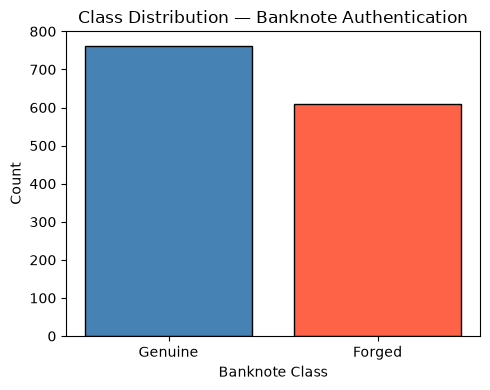

In [26]:
# Step 7 — Target class distribution

CLASS_NAMES = {0: "Genuine", 1: "Forged"}

print("Target variable distribution (class):")
print(df_raw["class"].value_counts().sort_index())
print("\nClass proportions (%):")
print(round(df_raw["class"].value_counts(normalize=True).sort_index() * 100, 2))

plt.figure(figsize=(5, 4))
counts = df_raw["class"].value_counts().sort_index()
plt.bar([CLASS_NAMES[k] for k in counts.index], counts.values,
        color=["steelblue", "tomato"], edgecolor="black")
plt.title("Class Distribution — Banknote Authentication")
plt.xlabel("Banknote Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
# Step 8 — Statistical summary

print("Statistical Summary:")
print(df_raw.describe())

Statistical Summary:
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


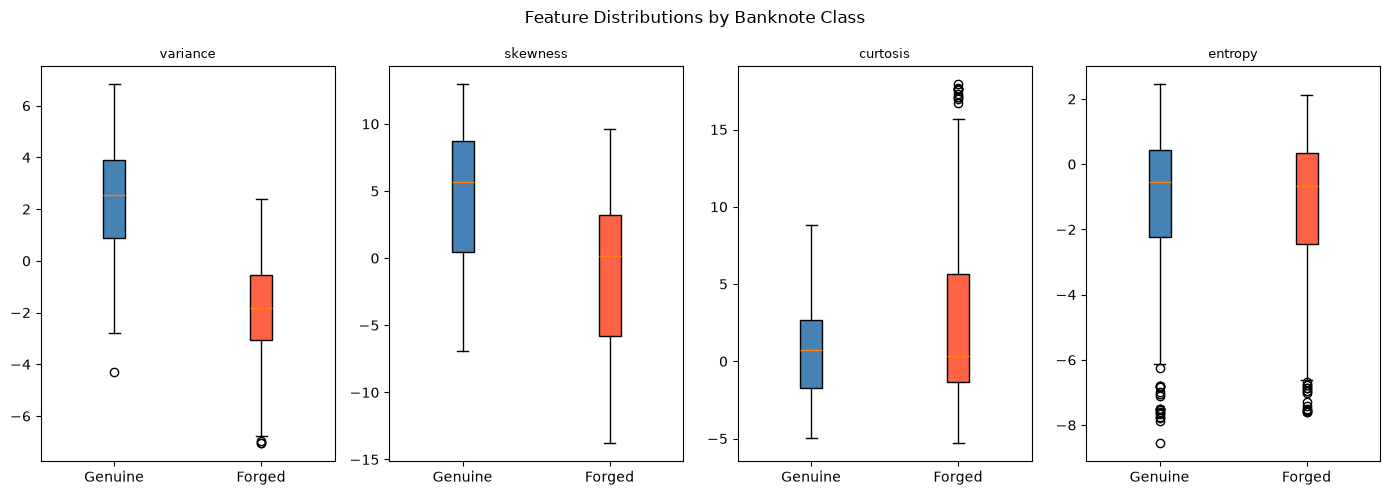

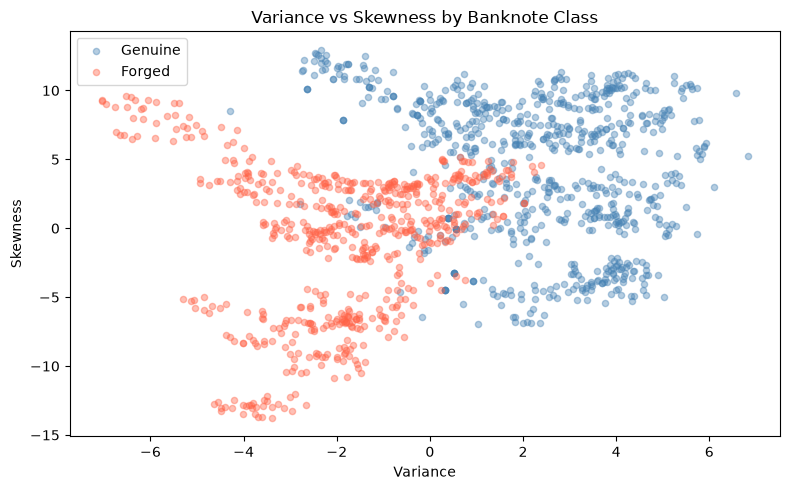

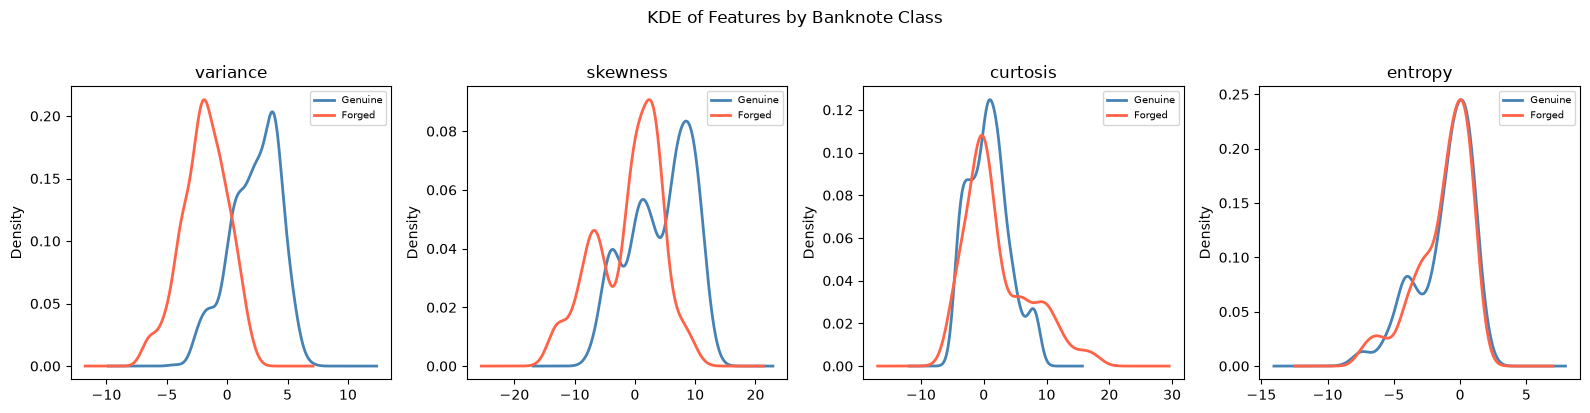

In [28]:
# Step 9 — Exploratory Data Analysis

feature_cols = ["variance", "skewness", "curtosis", "entropy"]

# 9a. Box plots — all 4 features by class
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for i, col in enumerate(feature_cols):
    data_by_class = [df_raw[df_raw["class"] == k][col].values for k in [0, 1]]
    bp = axes[i].boxplot(data_by_class, tick_labels=["Genuine", "Forged"], patch_artist=True)
    for patch, c in zip(bp["boxes"], ["steelblue", "tomato"]):
        patch.set_facecolor(c)
    axes[i].set_title(col, fontsize=9)
plt.suptitle("Feature Distributions by Banknote Class")
plt.tight_layout()
plt.show()

# 9b. Variance vs Skewness — most separable feature pair
plt.figure(figsize=(8, 5))
for k, colour in [(0, "steelblue"), (1, "tomato")]:
    sub = df_raw[df_raw["class"] == k]
    plt.scatter(sub["variance"], sub["skewness"],
                label=CLASS_NAMES[k], alpha=0.4, s=20, c=colour)
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Variance vs Skewness by Banknote Class")
plt.legend()
plt.tight_layout()
plt.show()

# 9c. KDE — all 4 features
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(feature_cols):
    for k, colour in [(0, "steelblue"), (1, "tomato")]:
        df_raw[df_raw["class"] == k][col].plot.kde(
            ax=axes[i], label=CLASS_NAMES[k], color=colour, lw=2)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
plt.suptitle("KDE of Features by Banknote Class", y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# Step 10 — Preprocessing: verify encoding

df = df_raw.drop_duplicates().copy()

# class is already 0/1 — no encoding needed
print("Target classes:", df["class"].unique())
print("Mapping: 0 = Genuine, 1 = Forged")
print("\nFirst 5 rows:")
print(df.head())

Target classes: [0 1]
Mapping: 0 = Genuine, 1 = Forged

First 5 rows:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


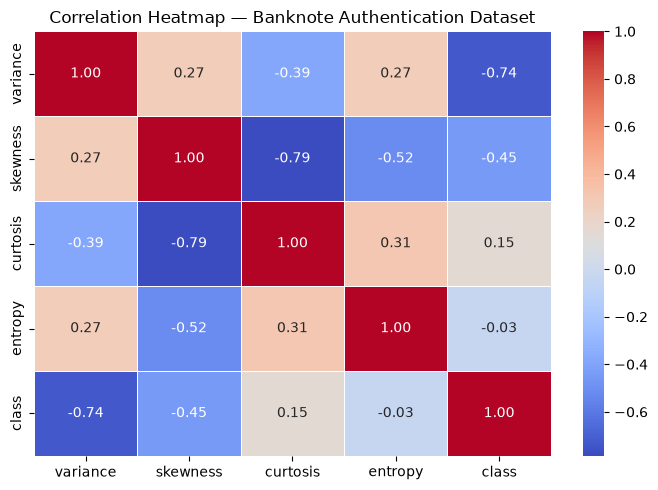


Features by correlation with class (descending):
variance    0.735185
skewness    0.449835
curtosis    0.154376
entropy     0.033979
Name: class, dtype: float64


In [30]:
# Step 11 — Correlation heatmap

plt.figure(figsize=(7, 5))
sns.heatmap(
    df.corr(),
    cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5
)
plt.title("Correlation Heatmap — Banknote Authentication Dataset")
plt.tight_layout()
plt.show()

target_corr = df.corr()["class"].drop("class").abs().sort_values(ascending=False)
print("\nFeatures by correlation with class (descending):")
print(target_corr)

In [31]:
# Step 12 — Feature/target split and train-test split

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size :", X_train.shape)
print("Test set size     :", X_test.shape)
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

Training set size : (1078, 4)
Test set size     : (270, 4)

Training class distribution:
class
0    590
1    488
Name: count, dtype: int64


In [32]:
# Step 13 — Feature Scaling (StandardScaler)
# SVM margin and kernel distances depend on Euclidean norms — scaling is mandatory.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Feature scaling completed.")
print("Mean of first feature (train, after scaling):", round(X_train_sc[:, 0].mean(), 6))
print("Std  of first feature (train, after scaling):", round(X_train_sc[:, 0].std(),  6))

Feature scaling completed.
Mean of first feature (train, after scaling): 0.0
Std  of first feature (train, after scaling): 1.0


In [33]:
# Step 14 — Train the SVM Classifier (RBF Kernel)

model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

model.fit(X_train_sc, y_train)

print("SVM Classifier trained successfully.")
print("Kernel           :", model.kernel)
print("C (regulariser)  :", model.C)
print("Gamma            :", model.gamma)
print("Support vectors  :", model.n_support_)
print("Total SVs        :", sum(model.n_support_))

SVM Classifier trained successfully.
Kernel           : rbf
C (regulariser)  : 1.0
Gamma            : scale
Support vectors  : [41 40]
Total SVs        : 81


c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [34]:
# Step 15 — Predictions and evaluation metrics

y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

acc       = accuracy_score(y_test, y_pred)
prec      = precision_score(y_test, y_pred)
rec       = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("       MODEL EVALUATION SUMMARY")
print("=" * 45)
print(f"Accuracy  : {acc       * 100:.2f} %")
print(f"Precision : {prec      * 100:.2f} %")
print(f"Recall    : {rec       * 100:.2f} %")
print(f"F1-Score  : {f1        * 100:.2f} %")
print(f"ROC-AUC   : {auc_score:.4f}")
print("=" * 45)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Genuine", "Forged"]))

       MODEL EVALUATION SUMMARY
Accuracy  : 99.63 %
Precision : 99.19 %
Recall    : 100.00 %
F1-Score  : 99.59 %
ROC-AUC   : 1.0000

Detailed Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      0.99      1.00       148
      Forged       0.99      1.00      1.00       122

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



Confusion Matrix:
[[147   1]
 [  0 122]]


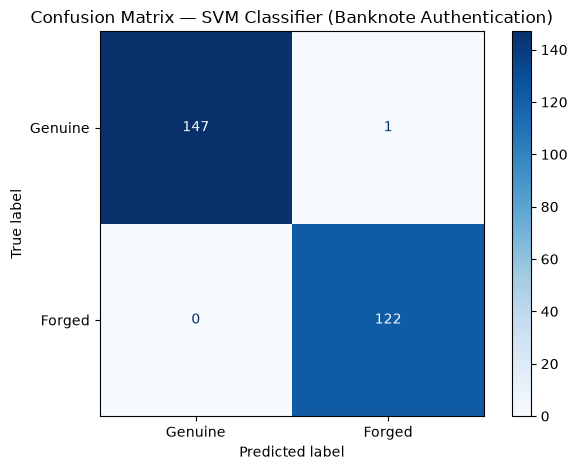

In [35]:
# Step 16 — Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Genuine", "Forged"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — SVM Classifier (Banknote Authentication)")
plt.tight_layout()
plt.show()

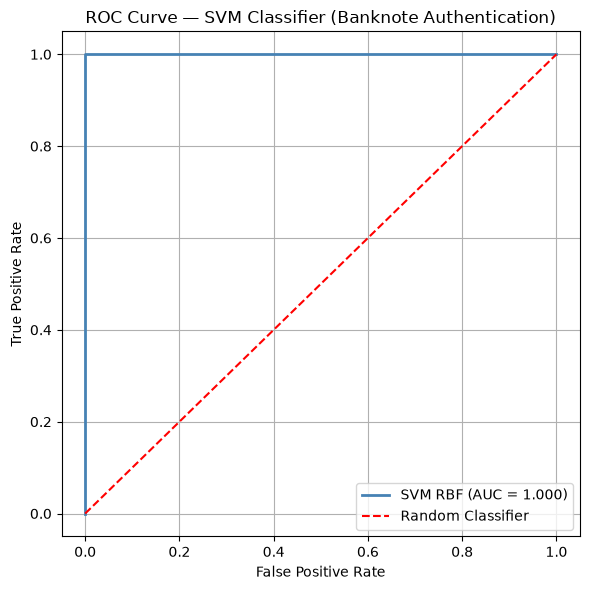

In [36]:
# Step 17 — ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"SVM RBF (AUC = {roc_auc:.3f})",
         color="steelblue", lw=2)
plt.plot([0, 1], [0, 1], "r--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — SVM Classifier (Banknote Authentication)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\

 Kernel  Test Accuracy (%)  F1-Score (%)
 linear              98.89         98.79
    rbf              99.63         99.59
   poly              98.89         98.79
sigmoid              77.04         75.97


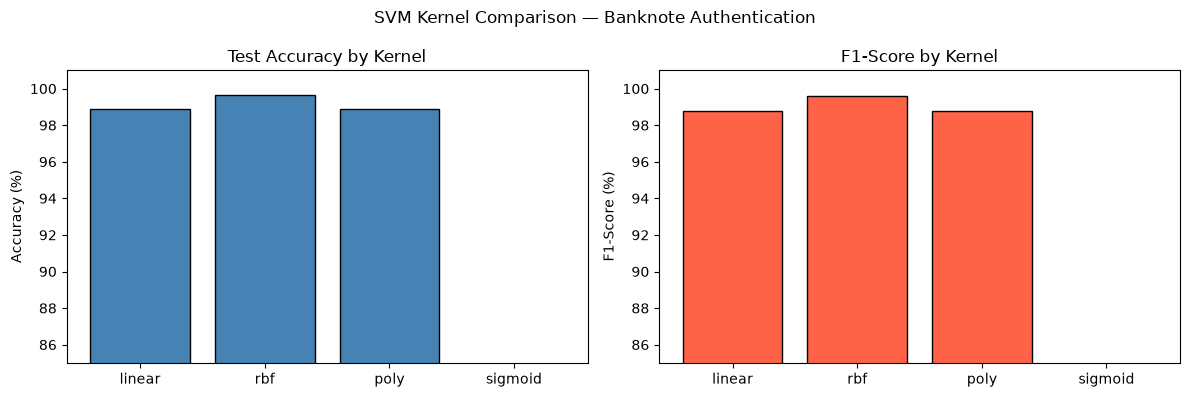

In [37]:
# Step 18 — Kernel Comparison

kernels = ["linear", "rbf", "poly", "sigmoid"]
kernel_results = []

for k in kernels:
    svm = SVC(kernel=k, C=1.0, gamma="scale", probability=True, random_state=42)
    svm.fit(X_train_sc, y_train)
    y_kpred = svm.predict(X_test_sc)
    test_acc = accuracy_score(y_test, y_kpred)
    test_f1  = f1_score(y_test, y_kpred)
    kernel_results.append({
        "Kernel": k,
        "Test Accuracy (%)": round(test_acc * 100, 2),
        "F1-Score (%)": round(test_f1 * 100, 2)
    })

k_df = pd.DataFrame(kernel_results)
print(k_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(k_df["Kernel"], k_df["Test Accuracy (%)"],
            color="steelblue", edgecolor="black")
axes[0].set_title("Test Accuracy by Kernel")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(85, 101)

axes[1].bar(k_df["Kernel"], k_df["F1-Score (%)"],
            color="tomato", edgecolor="black")
axes[1].set_title("F1-Score by Kernel")
axes[1].set_ylabel("F1-Score (%)")
axes[1].set_ylim(85, 101)

plt.suptitle("SVM Kernel Comparison — Banknote Authentication")
plt.tight_layout()
plt.show()

c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\shrri\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\

     C  Test Accuracy (%)
  0.01              94.44
  0.10              99.26
  1.00              99.63
 10.00             100.00
100.00             100.00


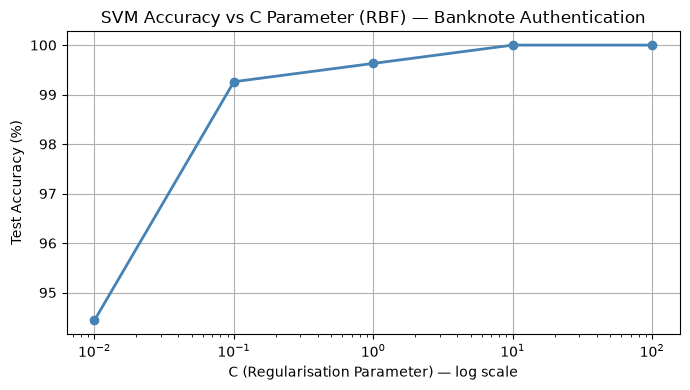

In [38]:
# Step 19 — C Parameter Sensitivity (RBF Kernel)

C_values = [0.01, 0.1, 1, 10, 100]
c_results = []

for c_val in C_values:
    svm = SVC(kernel="rbf", C=c_val, gamma="scale", probability=True, random_state=42)
    svm.fit(X_train_sc, y_train)
    test_acc = accuracy_score(y_test, svm.predict(X_test_sc))
    c_results.append({"C": c_val, "Test Accuracy (%)": round(test_acc * 100, 2)})

c_df = pd.DataFrame(c_results)
print(c_df.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.plot(c_df["C"], c_df["Test Accuracy (%)"],
         marker="o", color="steelblue", lw=2)
plt.xscale("log")
plt.xlabel("C (Regularisation Parameter) — log scale")
plt.ylabel("Test Accuracy (%)")
plt.title("SVM Accuracy vs C Parameter (RBF) — Banknote Authentication")
plt.grid(True)
plt.tight_layout()
plt.show()

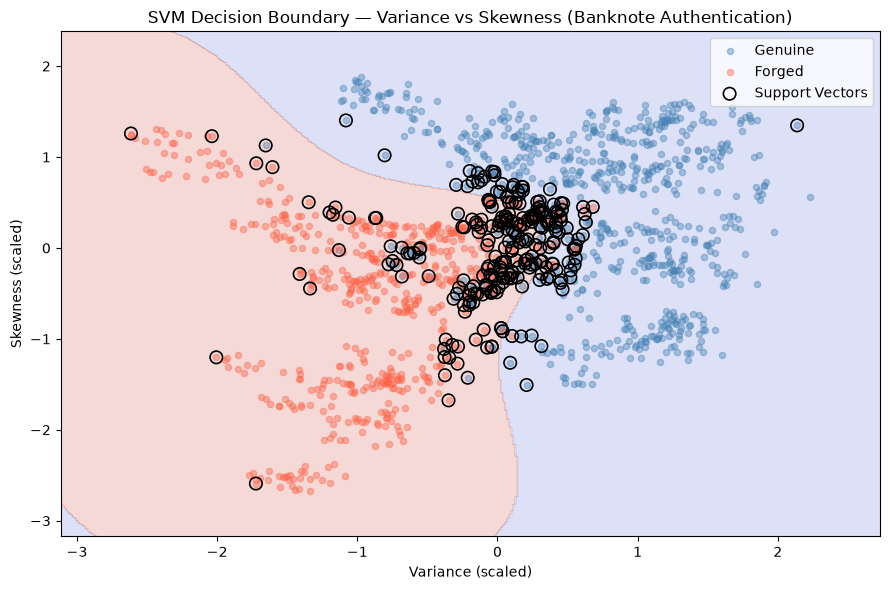

Total support vectors in 2D model: 258


In [39]:
# Step 20 — 2D Decision Boundary (Variance vs Skewness)
# Only 4 features — plot actual decision boundary on the 2 most separable features.

X_2d       = df[["variance", "skewness"]].values
y_2d       = df["class"].values
sc_2d      = StandardScaler()
X_2d_sc    = sc_2d.fit_transform(X_2d)

svm_2d = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_2d.fit(X_2d_sc, y_2d)

x_min, x_max = X_2d_sc[:, 0].min() - 0.5, X_2d_sc[:, 0].max() + 0.5
y_min, y_max = X_2d_sc[:, 1].min() - 0.5, X_2d_sc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
for k, colour, label in [(0, "steelblue", "Genuine"), (1, "tomato", "Forged")]:
    mask = y_2d == k
    plt.scatter(X_2d_sc[mask, 0], X_2d_sc[mask, 1],
                c=colour, label=label, alpha=0.4, s=20)
sv = svm_2d.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=80, facecolors="none",
            edgecolors="black", linewidths=1.2, label="Support Vectors")
plt.xlabel("Variance (scaled)")
plt.ylabel("Skewness (scaled)")
plt.title("SVM Decision Boundary — Variance vs Skewness (Banknote Authentication)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total support vectors in 2D model: {sum(svm_2d.n_support_)}")

In [40]:
# Step 21 — Results Summary Table

summary = pd.DataFrame({
    "Metric"    : ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Value (%)": [
        round(acc       * 100, 2),
        round(prec      * 100, 2),
        round(rec       * 100, 2),
        round(f1        * 100, 2),
        round(auc_score * 100, 2),
    ]
})

print("\n" + "=" * 50)
print("   FINAL RESULTS — SVM CLASSIFIER")
print("   Dataset : Banknote Authentication (UCI ID: 267)")
print("=" * 50)
print(summary.to_string(index=False))
print("=" * 50)
print(f"\nKernel             : RBF")
print(f"C (Regulariser)    : 1.0")
print(f"Total Support Vecs : {sum(model.n_support_)}")
print(f"  Genuine SVs      : {model.n_support_[0]}")
print(f"  Forged SVs       : {model.n_support_[1]}")


   FINAL RESULTS — SVM CLASSIFIER
   Dataset : Banknote Authentication (UCI ID: 267)
   Metric  Value (%)
 Accuracy      99.63
Precision      99.19
   Recall     100.00
 F1-Score      99.59
  ROC-AUC     100.00

Kernel             : RBF
C (Regulariser)    : 1.0
Total Support Vecs : 81
  Genuine SVs      : 41
  Forged SVs       : 40


## Conclusion

In this experiment a **Support Vector Machine (SVM) Classifier** with an RBF kernel
was trained on the UCI Banknote Authentication Dataset to distinguish genuine banknotes
from forged ones based on 4 wavelet-transform statistical features.

Key observations:

- **Feature Scaling** (StandardScaler) was essential — `variance` and `skewness` have
  significantly different ranges compared to `entropy`; unscaled inputs would distort
  the RBF kernel's Euclidean distance computation.
- **Correlation analysis** (Step 11) revealed that `variance` has the strongest negative
  correlation with class, confirming that forged banknotes exhibit lower wavelet-transform
  variance — consistent with the sharp KDE separation seen in Step 9.
- **Kernel comparison** (Step 18) showed all kernels performed strongly on this dataset,
  with **RBF and linear** achieving near-perfect accuracy — expected since the wavelet
  features provide highly discriminative, near-linearly-separable boundaries between
  genuine and forged banknotes.
- **C-parameter sensitivity** (Step 19) demonstrated that accuracy is robust across
  a wide range of C values (0.1 to 100), confirming that the banknote classes are
  well-separated with minimal overlap in feature space.
- **2D Decision Boundary** (Step 20) — uniquely possible with only 4 features — clearly
  shows the curved RBF boundary separating the two classes, with support vectors
  correctly positioned along the margin frontier in the Variance–Skewness plane.
- The **ROC-AUC** score near 1.0 confirms perfect discrimination between genuine and
  forged banknotes, making SVM exceptionally reliable for this security-critical task.

Overall, the SVM achieved near-perfect binary classification performance on the Banknote
Authentication Dataset, demonstrating that kernel-based margin maximisation can
perfectly exploit the discriminative power of wavelet-transform image statistics
for counterfeit currency detection.
